# Diabetes Prediction Analysis

## 1. Introduction and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading and Initial Inspection

In [ ]:
df=pd.read_csv('/content/diabetes.csv')

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**Observation:**


*   Here we see that null values are zero but there are possibility of hidden null values.
*   We start with checking for values like 0,-1,999,or blanks.



In [ ]:
print((df==0).sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


**Observation:**


*   From the dataset,we can say that the valid zeroes are those in outcomes and preganancies.


*   Remaining are invalid zeroes which are in place of null values.



## 3. Data Cleaning and Preprocessing

In [ ]:
df=df.drop(columns="SkinThickness")

In [ ]:
non_valid_zero_col=[
    'Glucose',
    'BloodPressure',
    'Insulin',
    'BMI']
df[non_valid_zero_col]=df[non_valid_zero_col].replace(0,np.nan)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.skew()

,0
Pregnancies,0.901674
Glucose,0.530989
BloodPressure,0.134153
Insulin,2.166464
BMI,0.593970
DiabetesPedigreeFunction,1.919911
Age,1.129597
Outcome,0.635017


In [ ]:
df[['Glucose','BMI']]=df[['Glucose','BMI']].fillna(df[['Glucose','BMI']].median())
df['BloodPressure']=df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['Insulin']=df.groupby('Outcome')['Insulin'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure     Insulin         BMI  \
count   768.000000  768.000000     768.000000  768.000000  768.000000   
mean      3.845052  121.656250      72.405184  141.753906   32.455208   
std       3.369578   30.438286      12.096346   89.100847    6.875177   
min       0.000000   44.000000      24.000000   14.000000   18.200000   
25%       1.000000   99.750000      64.000000  102.500000   27.500000   
50%       3.000000  117.000000      72.202592  102.500000   32.300000   
75%       6.000000  140.250000      80.000000  169.500000   36.600000   
max      17.000000  199.000000     122.000000  846.000000   67.100000   

       DiabetesPedigreeFunction         Age     Outcome  
count                768.000000  768.000000  768.000000  
mean                   0.471876   33.240885    0.348958  
std                    0.331329   11.760232    0.476951  
min                    0.078000   21.000000    0.000000  
25%                    0.243750   24.000000    0.000

##  Exploratory Data Analysis (EDA)

## 4.Univariate Analysis

### 4.1 Outcome Distribution

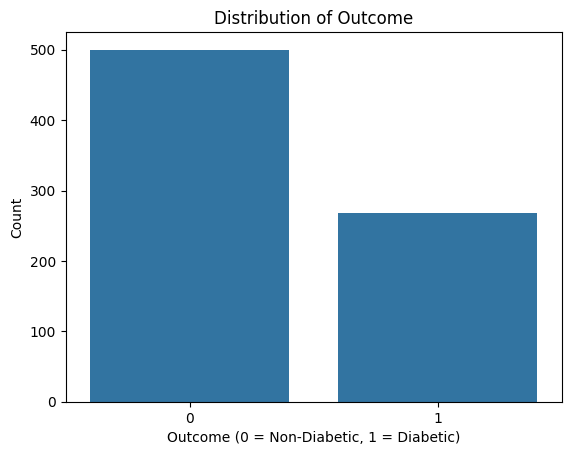

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

In [ ]:
print(df['Outcome'].value_counts())
print("\nOutcome percentage")
print(((df['Outcome'].value_counts()/len(df['Outcome']))*100).round(3).astype(str) + '%')

Outcome
0    500
1    268
Name: count, dtype: int64

Outcome percentage
Outcome
0    65.104%
1    34.896%
Name: count, dtype: object


### 4.2 Glucose Distribution

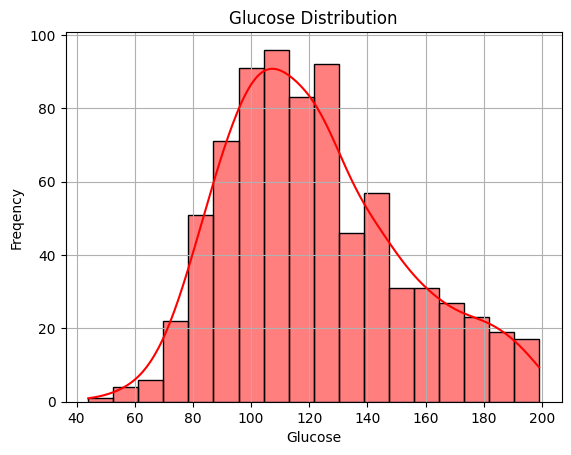

In [ ]:
sns.histplot(df['Glucose'],kde=True,color='red')
plt.xlabel('Glucose')
plt.ylabel('Freqency')
plt.title('Glucose Distribution')
plt.grid(True)
plt.show()



   **According to medical research on fasting glucose levels**:


*   **Normal**: 70-100 mg/dL
*   **Pre-diabetic**: 100-125 mg/dL


   

*   **Diabetic**: 126+ mg/dL





**Observations:**


*    The distribution is slightly right-skewed.

*    The majority group of people fall into the **pre-diabetic** range (99 to 125 mg/dL).
*    There are people with extremely high glucose levels, around **200 mg/dL**.


*   Some people also have extremely low glucose levels, around **40 mg/dL**.


      

* And very few people are in the category of normal blood glucose range of **70 to 100 mg/dL**  

  

### 4.3 BloodPressure Distribution

Text(0.5, 1.0, 'BloodPressure Boxplot')

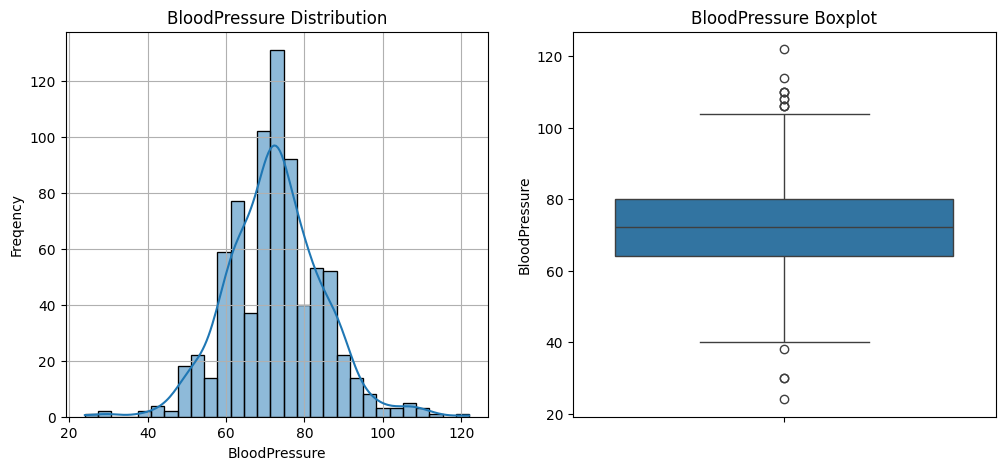

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(df['BloodPressure'],kde=True,ax=axes[0],line_kws={'color': 'red'})
axes[0].set_xlabel('BloodPressure')
axes[0].set_ylabel('Freqency')
axes[0].set_title('BloodPressure Distribution')
axes[0].grid(True)
sns.boxplot(df['BloodPressure'],ax=axes[1])
axes[1].set_title('BloodPressure Boxplot')

## Diastolic Blood Pressure Categories

**According to the American Heart Association:**

*   **Normal**: Less than 80 mm Hg
*   **Stage 1 Hypertension**: 80 to 89 mm Hg
*   **Stage 2 Hypertension**: 90 mm Hg or higher
*   **Hypertensive Crisis**: Higher than 120 mm Hg (Requires immediate medical attention)

**Observations from the graph:**

*   The distribution appears symmetric with no significant skewness.
*   Most people are found in the range of 60-79 mmHg, which is considered normal.
*   Outliers are present:
    *   Values above 120 mmHg indicate a hypertensive crisis and require immediate attention.
    *   Values below 40 mmHg indicate very low hypotension.

**From the boxplot:**

*   The median is moderately centered, indicating less skewness.
*  Point beyond the whiskers represent outliers.

### 4.4 Age Distribution

Text(0.5, 1.0, 'Age Distribution')

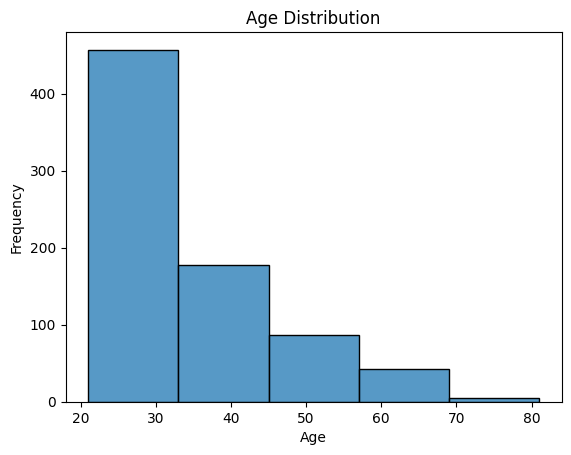

In [ ]:
sns.histplot(df['Age'],bins=5)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

**Observations:**


*   Most of the patients fall into the age category of **21 to 33 years**.
*   There are **no teens** in the dataset.
*   The dataset is dominated by **younger adults**.
*   The distribution is **right-skewed**.

### 4.5 Insulin Distribution

Number of outliers: 51
Insulin Max: 846.0
Insulin Median: 102.5
Highest count: 517
Range: 97.2 to 180.4


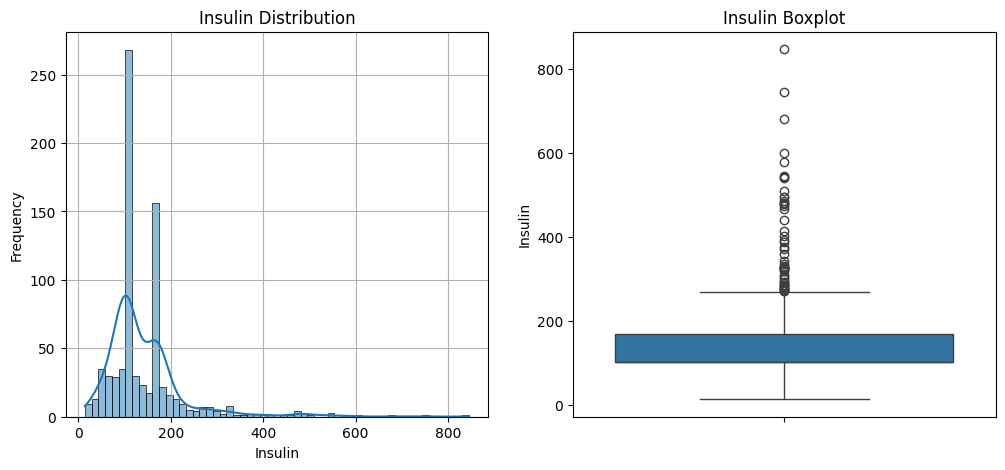

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(df['Insulin'],kde=True,ax=axes[0])
axes[0].set_xlabel('Insulin')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Insulin Distribution')
axes[0].grid(True)
sns.boxplot(df['Insulin'],ax=axes[1])
axes[1].set_title('Insulin Boxplot')


Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Insulin'] < Q1 - 1.5*IQR) |
              (df['Insulin'] > Q3 + 1.5*IQR)]
print(f"Number of outliers: {len(outliers)}")
print(f"Insulin Max: {df['Insulin'].max()}")
print(f"Insulin Median: {df['Insulin'].median()}")

counts, bins = np.histogram(df['Insulin'])
max_bin_index = np.argmax(counts)
print("Highest count:", counts[max_bin_index])
print("Range:",
      bins[max_bin_index],
      "to",
      bins[max_bin_index + 1])


**Post-glucose insulin range:**

*   **Normal:** 16 to 166 mIU/L




*   **Below 16 mIU/L (Low)**:not producing enough insulin and possible early Type 1 Diabetes.

*   **Above 166 mIU/L (High)**:Insulin resistance,Obesity,Early Type 2 Diabetes

 **Observations:**

*   The most frequent insulin levels is between **97 and 180 mIU/L**,indicating suggesting a pre-diabetic conditions.
*   The median insulin level is **102.5 mIU/L**, which is within the cited reference range.
*   The total of **51 outliers** is found with IQR method, with the highest recorded insulin level being **846 mIU/L**.

*   No values were found below the critical normal minimum.

*   The observed **bimodal distribution** in the Insulin graph implies the presence of multiple subgroups .

*Note:  These observations should be validated by domain experts before any clinical interpretation.*

### 4.6 BMI Categories

In [ ]:
df['BMI'].max()

67.1

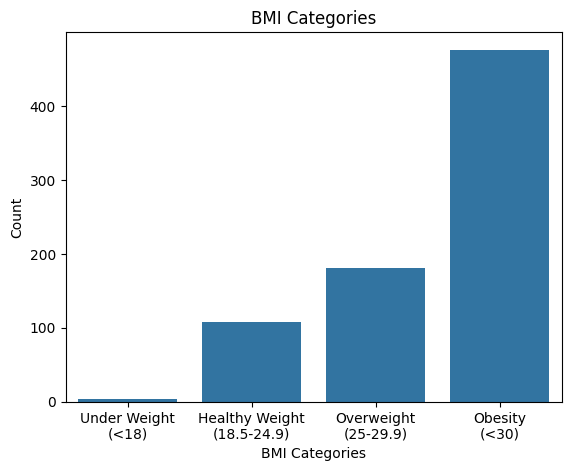

In [ ]:
df['BMI_Categories']=pd.cut(df['BMI'],bins=[0,18.5,25,30,67.1],
                            labels=[
                                'Under Weight\n(<18)',
                                'Healthy Weight\n(18.5-24.9)',
                                'Overweight\n(25-29.9)',
                                'Obesity\n(<30)'])
sns.countplot(x='BMI_Categories',data=df)
plt.title('BMI Categories')
plt.xlabel('BMI Categories')
plt.ylabel('Count')
plt.show()

**Observations :**


*   The **Obesity** group dominates the dataset.
*   This is followed by the **Overweight** category which forms significant proportion of dataset.
*   The **Healthy Weight** group comes next.
*   The **Underweight** category represents a very small portion of the dataset.

### 4.7 Diabetes Pedigree Function Categories

In [ ]:
df['DiabetesPedigreeFunction'].max()

2.42

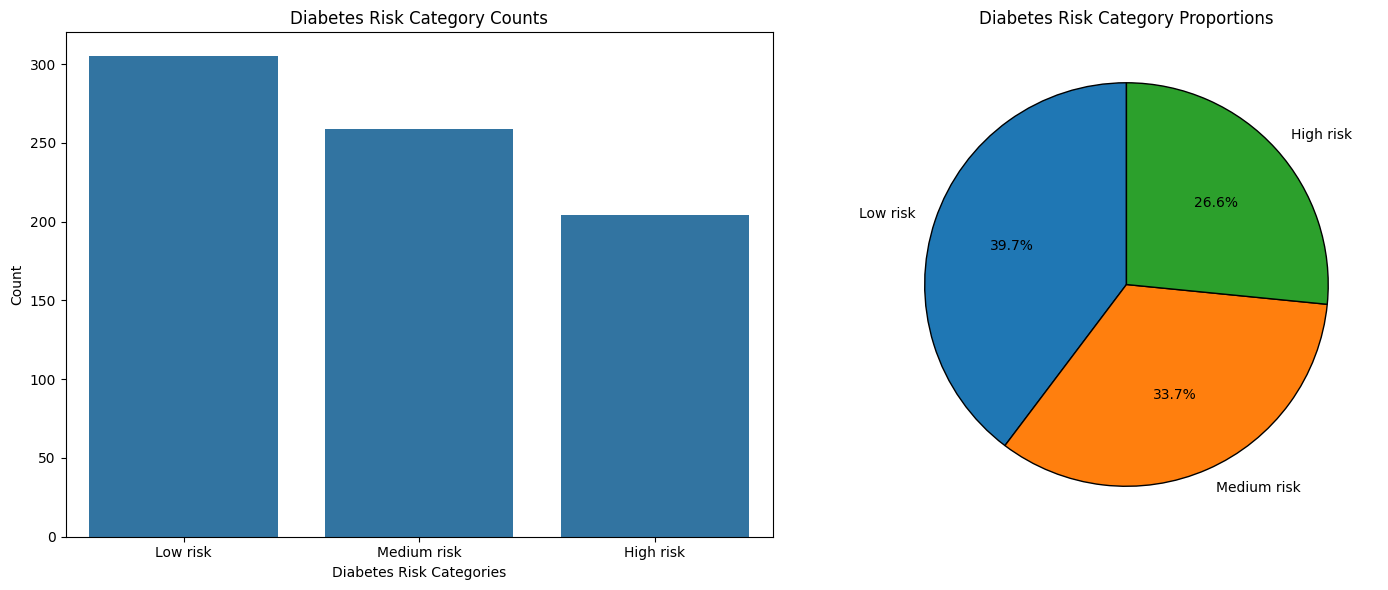

In [ ]:
a=pd.cut(df['DiabetesPedigreeFunction'],bins=[0,0.30,0.6,2.42],labels=['Low risk','Medium risk','High risk'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.countplot(x=a, data=df, ax=axes[0])
axes[0].set_title('Diabetes Risk Category Counts')
axes[0].set_xlabel('Diabetes Risk Categories')
axes[0].set_ylabel('Count')

category_counts =a.value_counts()
axes[1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Diabetes Risk Category Proportions')

plt.tight_layout()
plt.show()

**Diabetes Pedigree Function (DPF) Categories**

General Statistical Risk Categories

*   **Low Genetic Risk**: Below 0.30
*   **Medium / Moderate Genetic Risk**: 0.30 to 0.60
*   **High Genetic Risk**: Above 0.60

### 4.9 Glucose vs DiabetesPedigreeFunction Scatter Plot

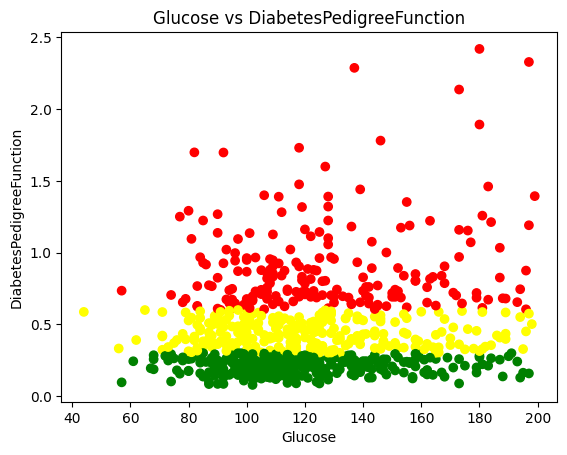

In [ ]:
df['Diabetes_Risk_Categories']=pd.cut(df['DiabetesPedigreeFunction'],bins=[0,0.30,0.6,2.42],labels=['Low risk','Medium risk','High risk'])
category_color={
    'Low risk':'green',
    'Medium risk':'yellow',
    'High risk':'red'

}
colors=df['Diabetes_Risk_Categories'].map(category_color)
plt.scatter(x=df['Glucose'],y=df['DiabetesPedigreeFunction'],c=colors)

plt.xlabel('Glucose')
plt.ylabel('DiabetesPedigreeFunction')
plt.title('Glucose vs DiabetesPedigreeFunction')

plt.show()

## 5. Correlation Analysis

In [ ]:
corr=df.corr(numeric_only=True)
print(corr)

                          Pregnancies   Glucose  BloodPressure   Insulin  \
Pregnancies                  1.000000  0.128213       0.208522  0.058767   
Glucose                      0.128213  1.000000       0.218749  0.488870   
BloodPressure                0.208522  0.218749       1.000000  0.066889   
Insulin                      0.058767  0.488870       0.066889  1.000000   
BMI                          0.021559  0.231049       0.281199  0.236674   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002763  0.146878   
Age                          0.544341  0.266909       0.324595  0.123629   
Outcome                      0.221898  0.492782       0.166074  0.377081   

                               BMI  DiabetesPedigreeFunction       Age  \
Pregnancies               0.021559                 -0.033523  0.544341   
Glucose                   0.231049                  0.137327  0.266909   
BloodPressure             0.281199                 -0.002763  0.324595   
Insulin            

## 6.Bivariate Analysis

### 6.1 Outcome VS Glucose

Text(0.5, 1.0, 'Outcome vs Glucose')

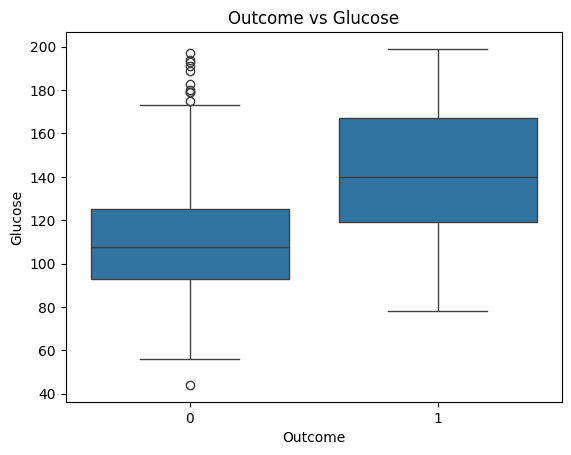

In [ ]:
sns.boxplot(x=df['Outcome'],y=df['Glucose'])
plt.xlabel('Outcome')
plt.ylabel('Glucose')
plt.title('Outcome vs Glucose')

In [ ]:
df.groupby('Outcome')['Glucose'].skew()

,Glucose
Outcome,
0,0.651964
1,0.104803


**Observations:**

*   Diabetic patients (Outcome = 1) have a **higher median** glucose level than non-diabetic patients.
*   Several high-glucose outliers are present in the non-diabetic group who may be have prediabetic conditions.
*   Outcome = 0 is moderately right-skewed (skewness = 0.65)and Outcome = 1 is nearly symmetric (skewness = 0.10).
*   Glucose shows a **strong relationship** with diabetes outcome and appears to be an important predictor of diabetes.

### 6.2 Glucose vs Insulin

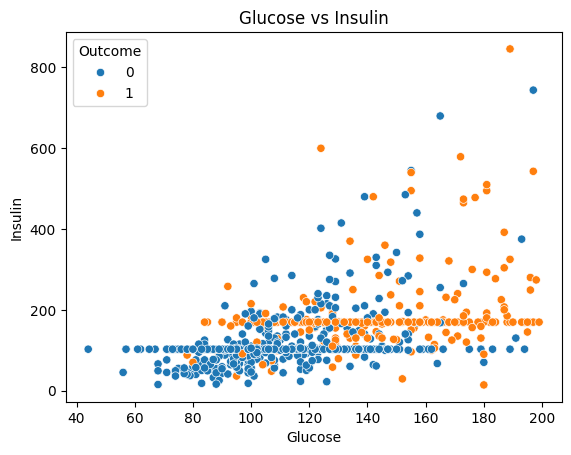

In [ ]:
sns.scatterplot(x=df['Glucose'],y=df['Insulin'],hue=df['Outcome'])
plt.xlabel('Glucose')
plt.ylabel('Insulin')
plt.title('Glucose vs Insulin')
plt.show()

**Observations:**

*  Insulin and Glucose exhibit a **positive relationship**, indicating that they are related to each other.

*  Non-diabetic patients are more in the region of **70 to 140 of Glucose** with insulin levels ranging from **50 to 200**. This says that many non-diabetic patients have moderate insulin levels.

*   Diabetic patients are in the region of **150 to 200 of Glucose** with high levels of insulin. This indicates that both insulin and glucose play a crucial role in determining diabetes.

* There are also extreme outliers present in the dataset which might indicate some very rare diabetic condition or measurement errors.

### 6.3 BMI VS Glucose

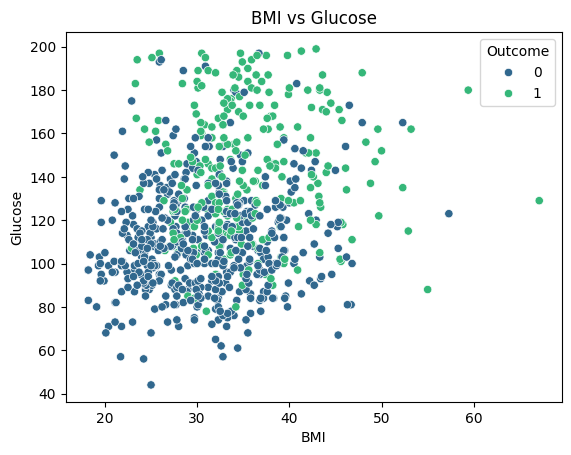

In [ ]:
sns.scatterplot(x=df['BMI'],y=df['Glucose'],hue=df['Outcome'], palette='viridis')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.title('BMI vs Glucose')
plt.show()

**Observations:**
*  There is **no distinct clustering** that clearly separates diabetic (Outcome = 1) and non-diabetic (Outcome = 0) patients based only on BMI and Glucose.

*   Many overweight individuals (BMI 25-40) are seen in higher glucose levels.

*    Non-diabetic patients are seen in all BMI ranges, indicating that BMI alone cannot indicate diabetes.

* Glucose appears to be a stronger factor for diabetes than BMI. Green dots (diabetic patients)are more in the upper region (indicating higher glucose levels) regardless of their BMI. And blue dots (non-diabetic patients) are more in the lower glucose range.

*  The relationship between BMI and glucose is weak.

### 6.4 Age VS Outcome

Text(0.5, 1.0, 'Age vs Outcome')

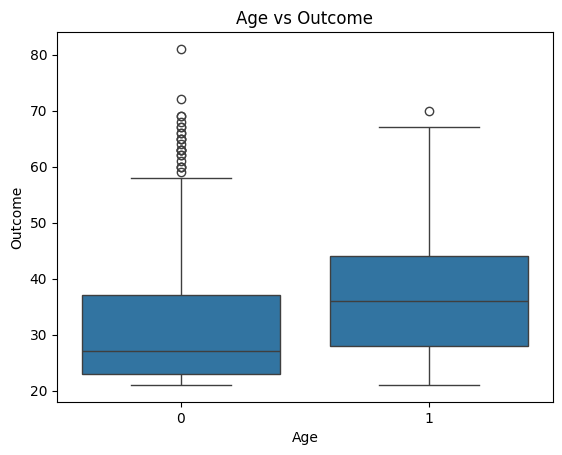

In [ ]:
sns.boxplot(x=df['Outcome'],y=df['Age'])
plt.xlabel('Age')
plt.ylabel('Outcome')
plt.title('Age vs Outcome')



**Observations:**

*  Diabetic patients are mostly older compared to non-diabetic patients. This says that age is a contributing factor to diabetes risk.

*   Non-diabetic patients show several older outliers above 60, indicating that some older individuals are non-diabetic despite their age.


* Diabetic patients have a higher median age which is around 36 compared
  to non-diabetic patients which is around 27.

* The overlap region indicates that age alone
  cannot determine diabetes status.

## 7.Multivariate Analysis

### 7.1 Correlation Heatmap

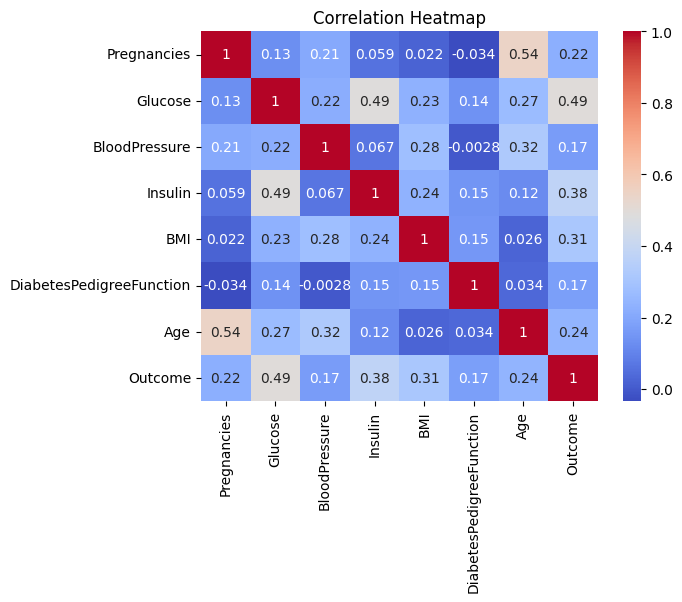

In [ ]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Correlation Matrix Analysis**



*   **Glucose and Outcome**: `Glucose` shows the strongest positive correlation with `Outcome` (diabetes), confirming its role as a primary predictor.

*   **BMI and Insulin**: `BMI` and `Insulin` also exhibit moderate positive correlations with `Outcome`, indicating their significance in diabetes prediction.

*   **Glucose and Insulin**: `Glucose` and `Insulin` are strongly correlated with each other, which is consistent with patterns observed in insulin resistance.

*   **Age, Outcome, and BloodPressure**: `Age` shows a moderate correlation with both `Outcome` and `BloodPressure`, suggesting that older patients tend to have higher blood pressure and are at increased risk of diabetes.

**Overall Insights:**


*   Glucose is the main strong indicator of the diabetes.
*   Insulin also plays a crucial role in indicating the presence of diabetes because of its moderate relationship with diabetes.


*   Age factor acts as influential factor as presence of diabetes is seen in most old people.




**Conclusion:**

  Thus the dataset is cleaned and data insights are taken from the dataset by the exploratory data analaysis process.